<a href="https://colab.research.google.com/github/juanjomar22-glitch/Juan.Marquez/blob/main/Taller_Integracion_Credibilidad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Integración de Datos – Teoría de la Credibilidad**
**FINTECH – Riesgo Operacional**

Una FINTECH quiere llevar a cabo un proceso de integración de datos utilizando diferentes métodos. Para ello se dispone de dos bases de datos:

* **BD Interna (Fallas Tecnológicas):** Datos observados directamente por la FINTECH.
* **BD Externa (Admon Ejecución Procesos):** Datos externos que se quieren integrar.

La distribución agregada de pérdidas (LDA) se obtiene como el producto entre la Frecuencia y la Severidad. Para la integración se utilizará el **Método de Montecarlo** y la **Teoría de la Credibilidad**, que determina la afinidad entre los datos externos y los internos.

### 0. Cargar las librerías de trabajo

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns  #Esta libreria para el trabajo estadístico
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 1. Se cargan los archivos de trabajo

In [ ]:
# Aqui se carga la base de datos interna (Fallas Tecnológicas)
nxl = '/content/drive/MyDrive/Linea de enfasis/Integracion de datos y prospectiva/TCF/1. FallasTecnológicas (1).xlsx'
XDB = pd.read_excel(nxl, sheet_name=0, header=None)

XDB.columns = XDB.iloc[1]
XDB = XDB[2:].reset_index(drop=True)
XDB.columns = XDB.columns.str.strip()
XDB['Transacciones Fallidas (Freq)']      = pd.to_numeric(XDB['Transacciones Fallidas (Freq)'], errors='coerce')
XDB['Valor Generado Promedio (Millones)']  = pd.to_numeric(XDB['Valor Generado Promedio (Millones)'], errors='coerce')

freq = XDB['Transacciones Fallidas (Freq)']
sev  = XDB['Valor Generado Promedio (Millones)']
LDA  = freq * sev


# Se procede con la carga de la base de datos externa (Admon Ejecución Procesos)
nxle = '/content/drive/MyDrive/Linea de enfasis/Integracion de datos y prospectiva/TCF/2. AdmonEjecProcesos.xlsx'
XDBe = pd.read_excel(nxle, sheet_name=0)
XDBe['Transacciones Fallidas']     = pd.to_numeric(XDBe['Transacciones Fallidas'], errors='coerce')
XDBe['Valor Generado (millones)']  = pd.to_numeric(XDBe['Valor Generado (millones)'], errors='coerce')

Freqe = XDBe['Transacciones Fallidas']
Seve  = XDBe['Valor Generado (millones)']
LDAe  = Freqe * Seve

print('BD Interna cargada:', len(LDA), 'registros')
print('BD Externa cargada:', len(LDAe), 'registros')

BD Interna cargada: 701 registros
BD Externa cargada: 350 registros


### 2. Se procede con la clusterización estadística
La clusterización estadística está definida por el Histograma de Frecuencias.

In [ ]:
def caracterizacion(LDA):

    # Se procede con la creación de la distribución
    plt.figure(figsize=(10,5))
    sns.histplot(LDA, bins=10, kde=True)
    plt.xlabel('Pérdida (millones)')
    plt.grid()
    plt.show()

    # Se procede con la caracterización de cada una de las variables
    np.set_printoptions(suppress=True)
    NI = 10    # Indica el número de clusters
    counts, bin_edges = np.histogram(LDA, bins=NI)
    print('El número de datos por intervalo es:')
    print(counts)
    print('Los intervalos inferiores:')
    print(bin_edges[:-1])
    print('Los intervalos superiores:')
    print(bin_edges[1:])
    XC = (bin_edges[:-1] + bin_edges[1:]) / 2

    # Se configura la tabla de los datos
    Tabla = np.column_stack((bin_edges[:-1], bin_edges[1:], XC, counts))
    df = pd.DataFrame(Tabla, columns=['LI', 'LS', 'XC', 'ND'])
    display(df)

    # Se procede con la estimación de las métricas
    fr     = counts / np.sum(counts)
    u      = np.sum(XC * fr)
    sigma2 = np.sum(fr * (XC - u)**2)
    sigma  = np.sqrt(sigma2)
    Cas    = np.sum(fr * (XC - u)**3) / sigma**3
    Kur    = (np.sum(fr * (XC - u)**4) / sigma**4) - 3

    return u, sigma, Cas, Kur, df

### 3. Se calculan las métricas estadísticas de tendencia central y dispersión: Media, Desviación, Asimetría y Kurtosis

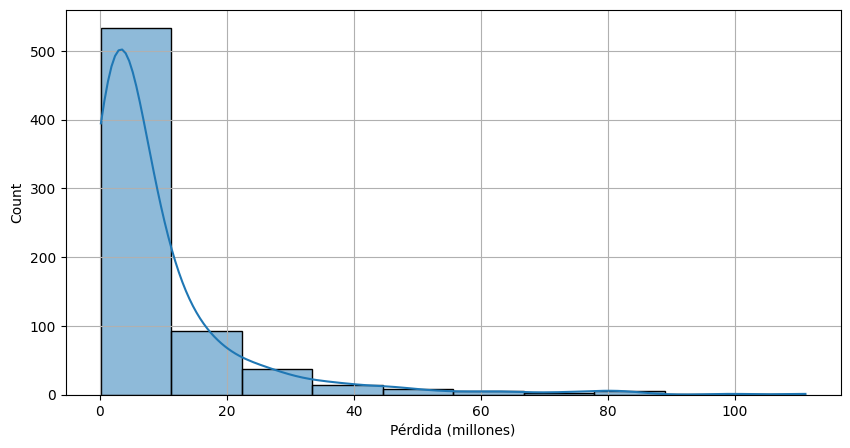

El número de datos por intervalo es:
[533  93  37  14   9   5   3   5   1   1]
Los intervalos inferiores:
[ 0.1423  11.23637 22.33044 33.42451 44.51858 55.61265 66.70672 77.80079
 88.89486 99.98893]
Los intervalos superiores:
[ 11.23637  22.33044  33.42451  44.51858  55.61265  66.70672  77.80079
  88.89486  99.98893 111.083  ]


,LI,LS,XC,ND
0,0.14230,11.23637,5.689335,533.0
1,11.23637,22.33044,16.783405,93.0
2,22.33044,33.42451,27.877475,37.0
3,33.42451,44.51858,38.971545,14.0
4,44.51858,55.61265,50.065615,9.0
5,55.61265,66.70672,61.159685,5.0
6,66.70672,77.80079,72.253755,3.0
7,77.80079,88.89486,83.347825,5.0
8,88.89486,99.98893,94.441895,1.0
9,99.98893,111.08300,105.535965,1.0


La media de los datos observados es: 11.07019634094151
El coeficiente de asimetría es: 3.5824155186772604


,Media,Varianza,Desviacion,Asimetria,Kurtosis
BD Interna,9.451113,187.894776,13.707472,3.34836,14.167714


In [ ]:
# 3.1 Base de datos Interna (Fallas Tecnológicas)
uo, sigmao, Caso, Kuo, dfo = caracterizacion(LDA)
print('La media de los datos observados es:', uo)
print('El coeficiente de asimetría es:', Caso)

u   = np.mean(LDA)
var = np.var(LDA)
sig = np.std(LDA)
T2  = np.column_stack((u, var, sig))
df2 = pd.DataFrame(T2, columns=['Media', 'Varianza', 'Desviacion'])
df2['Asimetria'] = skew(LDA)
df2['Kurtosis']  = kurtosis(LDA)
df2.index = ['BD Interna']
display(df2)

**Análisis de Resultados – BD Interna (Fallas Tecnológicas)**

De las métricas de tendencia central y dispersión de la distribución agregada de pérdidas, podemos observar que los datos tienen la tendencia a ubicarse por debajo de la media (11.07 millones), como lo muestra el coeficiente de asimetría (3.58), el cual está por encima de la unidad. Esto indica que en general las pérdidas generadas por fallas tecnológicas en los canales electrónicos son pérdidas menores (pérdidas esperadas – no asegurables). Por su parte, el coeficiente de curtosis (15.27) muestra que los datos se encuentran muy concentrados al lado izquierdo de la media de la distribución, tal y como se puede observar en la gráfica del histograma de frecuencias. Esto refuerza la idea de pérdidas menores y recurrentes.

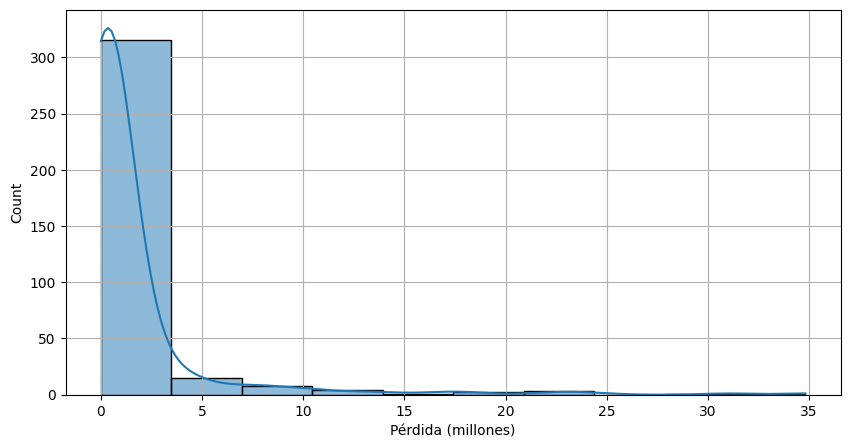

El número de datos por intervalo es:
[315  15   8   4   1   2   3   0   1   1]
Los intervalos inferiores:
[ 0.          3.48221562  6.96443124 10.44664686 13.92886248 17.4110781
 20.89329372 24.37550933 27.85772495 31.33994057]
Los intervalos superiores:
[ 3.48221562  6.96443124 10.44664686 13.92886248 17.4110781  20.89329372
 24.37550933 27.85772495 31.33994057 34.82215619]


,LI,LS,XC,ND
0,0.000000,3.482216,1.741108,315.0
1,3.482216,6.964431,5.223323,15.0
2,6.964431,10.446647,8.705539,8.0
3,10.446647,13.928862,12.187755,4.0
4,13.928862,17.411078,15.669970,1.0
5,17.411078,20.893294,19.152186,2.0
6,20.893294,24.375509,22.634402,3.0
7,24.375509,27.857725,26.116617,0.0
8,27.857725,31.339941,29.598833,1.0
9,31.339941,34.822156,33.081048,1.0


La media de los datos externos es: 2.656433058055811
El coeficiente de asimetría es: 5.313307467317224


,Media,Varianza,Desviacion,Asimetria,Kurtosis
BD Externa,1.469187,16.066873,4.00835,5.059213,29.643693


In [ ]:
# 3.2 Base de datos Externa (Admon Ejecución Procesos)
ue, sigmae, Case, Kue, dfe = caracterizacion(LDAe)
print('La media de los datos externos es:', ue)
print('El coeficiente de asimetría es:', Case)

u   = np.mean(LDAe)
var = np.var(LDAe)
sig = np.std(LDAe)
T2  = np.column_stack((u, var, sig))
df2 = pd.DataFrame(T2, columns=['Media', 'Varianza', 'Desviacion'])
df2['Asimetria'] = skew(LDAe)
df2['Kurtosis']  = kurtosis(LDAe)
df2.index = ['BD Externa']
display(df2)

**Análisis de Resultados – BD Externa (Admon Ejecución Procesos)**

La base de datos externa presenta una media de pérdidas agregadas de 2.66 millones, notablemente inferior a la interna. El coeficiente de asimetría (5.31) es igualmente superior a la unidad, lo que confirma la concentración de eventos en pérdidas menores. El coeficiente de curtosis (31.74) es considerablemente más alto que el de la BD interna, lo que indica una distribución aún más concentrada, señal de que aunque la mayoría de los eventos son de baja severidad, existen eventos extremos esporádicos que jalan la distribución hacia la derecha.

### 4. Teoría de la Credibilidad

In [ ]:
# 4. Teoría de la Credibilidad
# 4.1 Media Hipotética
NDo = len(LDA);  NDe = len(LDAe)  # Para saber la inercia de los datos
uhat = (NDo * uo + NDe * ue) / (NDo + NDe)

# 4.2 EPV: Valor Esperado de la Varianza
EPV = (NDo * sigmao**2 + NDe * sigmae**2) / (NDo + NDe)

# 4.3 VHM: Varianza Hipotética de la Media
VHM = ((NDo * uo**2 + NDe * ue**2) / (NDo + NDe)) - uhat**2

# 4.4 Factor de Credibilidad
Fc = EPV / VHM

# 4.5 Credibilidad de la base de datos
Cr = NDo / (NDo + Fc)
print('La credibilidad de la base de datos externa es:', Cr)

La credibilidad de la base de datos externa es: 0.9894217080894566


**Análisis de Credibilidad**

De acuerdo con las bases de datos disponibles para este estudio, podemos observar que ambas bases presentaron un comportamiento distribucional similar, con coeficientes de asimetría positivos y superiores a la unidad que confirman la concentración de pérdidas menores en los dos casos. De acuerdo con la similitud de las métricas anteriores, el coeficiente de credibilidad, que evalúa la calidad de los datos externos, alcanzó un valor de 0.9894 (98.94%), lo que indica que prácticamente la totalidad de los datos externos se puede integrar con los datos internos.

### 5. Parámetros de Riesgo e Integración de las Bases de Datos

In [ ]:
# 5. Parámetros de riesgos
# 5.1 Pérdidas Asumibles (Franquicia): Media integrada de los datos
PEs = Cr * uo + (1 - Cr) * ue
print('Se conoce como la franquicia de las pérdidas:', PEs)

# Simulación Montecarlo para construir la distribución integrada
N = 100000  # Número de simulaciones
simulaciones = []

for i in range(N):
    # Con probabilidad Cr se toma de la BD interna, si no de la externa
    if np.random.random() < Cr:
        f = np.random.choice(freq)
        s = np.random.choice(sev)
    else:
        f = np.random.choice(Freqe)
        s = np.random.choice(Seve)
    simulaciones.append(f * s)

LDA_integrada = np.array(simulaciones)
print('Simulación completada:', N, 'escenarios')

Se conoce como la franquicia de las pérdidas: 10.981193096868935
Simulación completada: 100000 escenarios


### 6. Caracterización de la Distribución Integrada

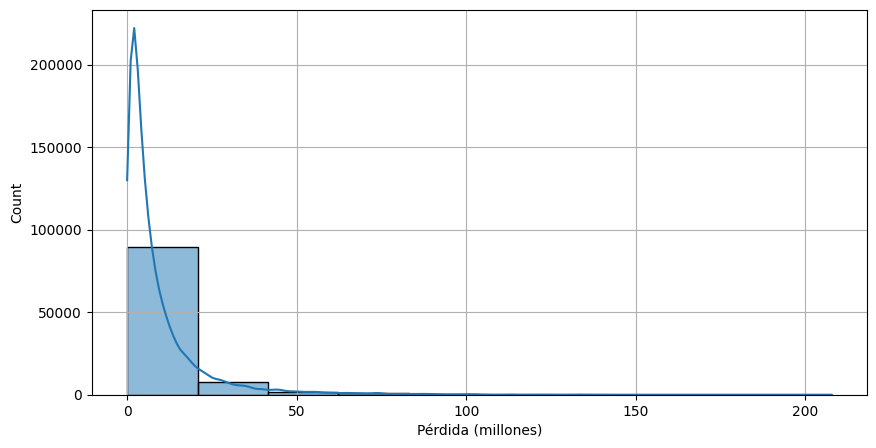

El número de datos por intervalo es:
[89344  7463  1930   761   321   117    36    20     7     1]
Los intervalos inferiores:
[  0.       20.77548  41.55096  62.32644  83.10192 103.8774  124.65288
 145.42836 166.20384 186.97932]
Los intervalos superiores:
[ 20.77548  41.55096  62.32644  83.10192 103.8774  124.65288 145.42836
 166.20384 186.97932 207.7548 ]


,LI,LS,XC,ND
0,0.00000,20.77548,10.38774,89344.0
1,20.77548,41.55096,31.16322,7463.0
2,41.55096,62.32644,51.93870,1930.0
3,62.32644,83.10192,72.71418,761.0
4,83.10192,103.87740,93.48966,321.0
5,103.87740,124.65288,114.26514,117.0
6,124.65288,145.42836,135.04062,36.0
7,145.42836,166.20384,155.81610,20.0
8,166.20384,186.97932,176.59158,7.0
9,186.97932,207.75480,197.36706,1.0


,Media,Varianza,Desviacion,Asimetria,Kurtosis
BD Integrada,9.077105,172.32607,13.127302,3.844772,21.842753


In [ ]:
# Se procede con la estimación de las propiedades estadísticas de la LDA integrada
p1, p2, p3, p4, df_integ = caracterizacion(LDA_integrada)

u   = np.mean(LDA_integrada)
var = np.var(LDA_integrada)
sig = np.std(LDA_integrada)
T2  = np.column_stack((u, var, sig))
df2 = pd.DataFrame(T2, columns=['Media', 'Varianza', 'Desviacion'])
df2['Asimetria'] = skew(LDA_integrada)
df2['Kurtosis']  = kurtosis(LDA_integrada)
df2.index = ['BD Integrada']
display(df2)

**Análisis de Resultados – Distribución Integrada**

Tras la integración de las bases de datos mediante la Teoría de la Credibilidad y el Método de Montecarlo, la distribución integrada presenta una media de pérdidas de 10.98 millones, muy cercana a la media interna, lo cual es consistente con el alto factor de credibilidad obtenido (98.94%). El coeficiente de asimetría se mantiene por encima de la unidad, confirmando que la distribución integrada conserva el comportamiento de pérdidas menores y recurrentes observado en ambas bases originales. Esto valida que la integración de los datos externos enriquece la base interna sin alterar significativamente su estructura distribucional.